#### Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import interp1d
import pickle
import os

TEMPLATE = "plotly_white"

print("Price Transmission Engine Initialized.")

Price Transmission Engine Initialized.


#### Simulating New York C-Market Data

In [2]:
dates = pd.date_range(start='2024-04-01', periods=24, freq='ME')

c_market_base = np.linspace(5.95, 9.30, 24) 
noise = np.random.normal(0, 0.15, 24)
c_market_prices = c_market_base + noise

price_df = pd.DataFrame({
    'date': dates,
    'export_price_fob': c_market_prices
})

print("Global Export (FOB) Benchmark established.")

Global Export (FOB) Benchmark established.


#### Applying the Transmission Elasticity

In [3]:
ELASTICITY = 0.72
FIXED_LOGISTICS_COST = 1.65
MIDDLEMAN_EXTRACTION = 0.15

def simulate_farmgate(fob_price):
    return (fob_price * ELASTICITY) - FIXED_LOGISTICS_COST - MIDDLEMAN_EXTRACTION

price_df['farmgate_price'] = price_df['export_price_fob'].apply(simulate_farmgate)

price_df['farmer_share_pct'] = (price_df['farmgate_price'] / price_df['export_price_fob']) * 100

print(f"Farmgate simulation complete. Mean Farmer Share: {price_df['farmer_share_pct'].mean():.2f}%")

Farmgate simulation complete. Mean Farmer Share: 47.75%


#### Visualizing the Transmission Gap

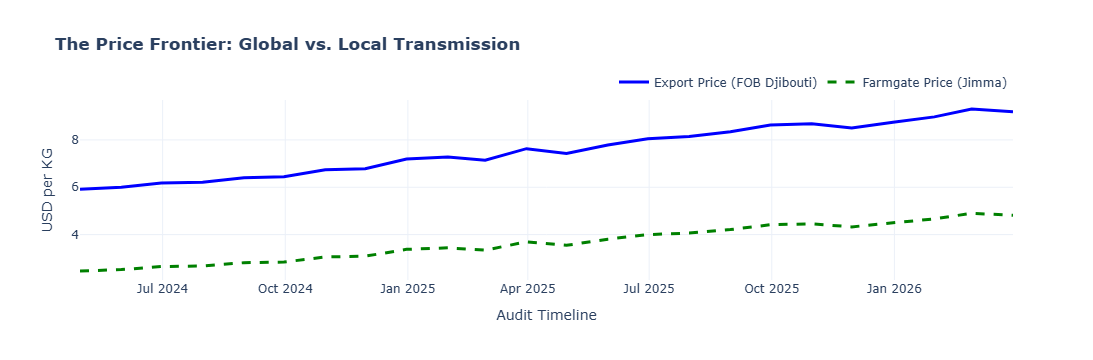

In [4]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=price_df['date'], y=price_df['export_price_fob'], 
                         name='Export Price (FOB Djibouti)', line=dict(color='blue', width=3)))

fig.add_trace(go.Scatter(x=price_df['date'], y=price_df['farmgate_price'], 
                         name='Farmgate Price (Jimma)', line=dict(color='green', width=3, dash='dash')))

fig.update_layout(title='<b>The Price Frontier: Global vs. Local Transmission</b>',
                  xaxis_title='Audit Timeline', yaxis_title='USD per KG',
                  template=TEMPLATE, legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

fig.show()

#### Save the price model

In [5]:
price_df.to_csv('../data/processed/price_transmission_baseline.csv', index=False)

print("Economic baseline saved.")

Economic baseline saved.


In [6]:
price_df.head()

,date,export_price_fob,farmgate_price,farmer_share_pct
0,2024-04-30,5.918180,2.461089,41.585242
1,2024-05-31,6.000136,2.520098,42.000680
2,2024-06-30,6.180356,2.649856,42.875463
3,2024-07-31,6.213472,2.673700,43.030690
4,2024-08-31,6.405360,2.811859,43.898534
